**DSCB230 Sommersemester 2026**
# Hausarbeit - Datenauswertung am Beispiel eines Business-Anwendungsfalls
Data Science Portfolioprojekt

**DSCB230 Sommersemester 2026**

# Hausarbeit - Unternehmensanaylse anhand des Aktienkurses
Data Science Portfolioprojekt

Gruppe | Studierende 1 | Studierende 2 |
------ | ------ | ------ |
`Foxtrot` | `Ivan Pedzin` | `Maximilian Hutter` |

## Business Case

Es sollen verschiedene Unternehemen, am Beispiel Apple, Microsoft und Samsung, auf Basis ihres Aktienkurses verglichen werden, um Investitionsentscheidungen zu treffen (Zeitraum 2000 - Jetzt).

Dabei werden speziel folgende Punkte untersucht:
- Allgemeiner grafischer Vergleich der Aktienkurse
- Rendite
- Volatilität
- gleitende Durchschnitte 
- Verhalten in Krisenzeiten (versuchen genau Punkte dazustellen)
- Am Beispiel Intel vom 4.5 (2. ZP) bis hin zur Präsentation entwicklung bei 1000€ Investition

## Datenerfassung und Datenvorverarbeitung

### Download des Datensatzes (Yahoo Finance API)

In [26]:
#%pip install yfinance
#%pip install matplotlib

In [27]:
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

heute = datetime.now().strftime('%Y-%m-%d')

### Erster Überblick über die Daten

In [28]:

# Ticker Symbole definieren
apple = yf.Ticker("AAPL")   #Apple
ms = yf.Ticker("MSFT")      #Microsoft
sa = yf.Ticker("SMSN.IL")   #Samsung

In [29]:
# Daten von 2000 - Jetzt abrufen und in liste speichern
hist_apple = apple.history(start="2000-01-01", end=heute)
hist_ms = ms.history(start="2000-01-01", end=heute)
hist_sa = sa.history(start="2000-01-01", end=heute)

In [30]:
# Die ersten 5 Zeilen der Daten anzeigen
print("Apple (AAPL)")
display(hist_apple.head())
print("Microsoft (MSFT)")
display(hist_ms.head())
print("Samsung (SMSN.IL)")
display(hist_sa.head())

Apple (AAPL)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,0.784870,0.841934,0.761015,0.837724,535796800,0.0,0.0
2000-01-04 00:00:00-05:00,0.810128,0.827902,0.757273,0.767096,512377600,0.0,0.0
2000-01-05 00:00:00-05:00,0.776450,0.827434,0.770837,0.778321,778321600,0.0,0.0
2000-01-06 00:00:00-05:00,0.794225,0.800773,0.710966,0.710966,767972800,0.0,0.0
2000-01-07 00:00:00-05:00,0.722192,0.755870,0.714709,0.744644,460734400,0.0,0.0


Microsoft (MSFT)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,35.767973,36.148889,34.130036,35.520378,53228400,0.0,0.0
2000-01-04 00:00:00-05:00,34.606182,35.691792,34.206221,34.320496,54119000,0.0,0.0
2000-01-05 00:00:00-05:00,33.863401,35.463246,33.330119,34.682369,64059600,0.0,0.0
2000-01-06 00:00:00-05:00,34.187179,34.701415,33.025386,33.520576,54976600,0.0,0.0
2000-01-07 00:00:00-05:00,33.101555,34.206209,32.701593,33.958614,62013600,0.0,0.0


Samsung (SMSN.IL)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2001-05-14 00:00:00+01:00,64.127375,64.127375,63.229233,63.588490,197500,0.0,0.0
2001-05-15 00:00:00+01:00,62.683179,63.732209,62.510737,62.733475,122000,0.0,0.0
2001-05-16 00:00:00+01:00,61.792201,62.704711,60.714430,60.894058,278900,0.0,0.0
2001-05-17 00:00:00+01:00,63.954951,64.580055,62.510736,64.299835,364300,0.0,0.0
2001-05-18 00:00:00+01:00,63.337024,64.666274,60.994667,64.256721,199100,0.0,0.0


### Datenbereinigung

#### Fehlende Werte checken

In [31]:
print(hist_apple.isnull().sum()) 
print(hist_ms.isnull().sum())
print(hist_sa.isnull().sum())
#mit isnull schauen ob ob zellen leer sind und ergeniss (true/False) aller zellen zusammenrechnen und ausgeben

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


#### Duplikate Checken

In [32]:
print(hist_apple.index.duplicated().sum())
print(hist_ms.index.duplicated().sum())
print(hist_sa.index.duplicated().sum())
# schaut ob ein datum (index) doppelt vorkommt und rechnet das ergebniss wieder zusammen

0
0
0


####Samsung GDR in einzel Aktien umrechnen

In [33]:
# Samsung Kurse durch 25 teilen (ILS → USD Umrechnung)
hist_sa["Close"] = hist_sa["Close"] / 25
hist_sa["Open"] = hist_sa["Open"] / 25
hist_sa["High"] = hist_sa["High"] / 25
hist_sa["Low"] = hist_sa["Low"] / 25
#durch 25 teilen da es sich bei der Samsung Aktie um einen GDR(Global Depositary Receipt) handelt, welcher 25 Stammaktien repräsentiert

## Analyse der Daten

### Kursvergleiche

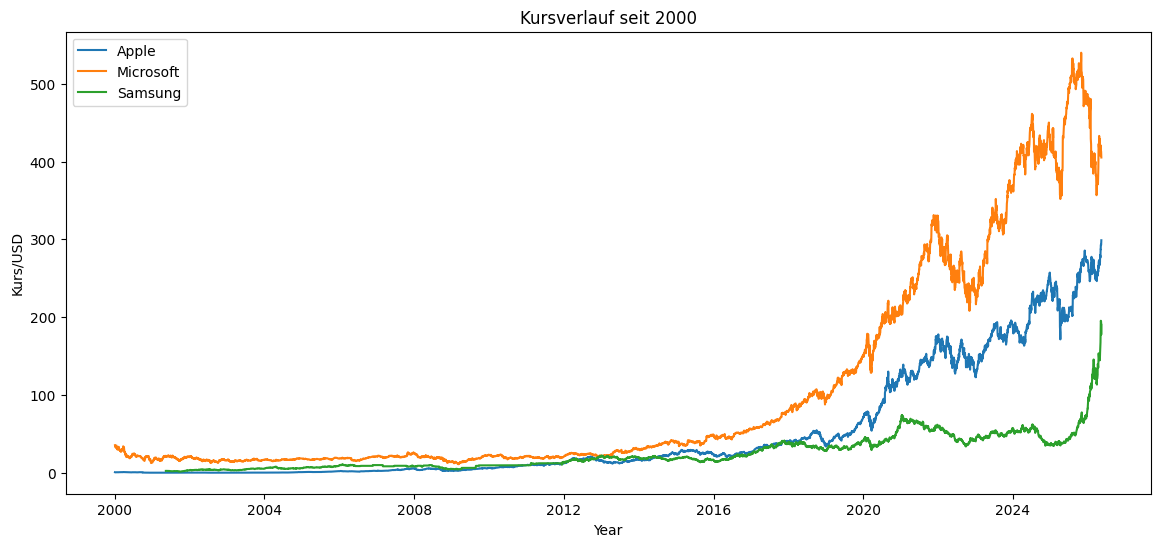

In [46]:
plt.figure(figsize=(14, 6))
plt.plot(hist_apple["Close"], label = "Apple")
plt.plot(hist_ms["Close"], label = "Microsoft")
plt.plot(hist_sa["Close"], label = "Samsung")
plt.title("Kursverlauf seit 2000")
plt.xlabel("Year")
plt.ylabel("Kurs/USD")
plt.legend()
plt.show()

## Lessons Learned